
# Modelo Novo-Keynesiano de Economia Fechada e Aberta

**Autoría:** Grupo FISLAC – Banco Interamericano de Desarrollo. **Colaboração:** Ministério da Fazenda do Brasil. **Fecha:** Janeiro 2026.


In [1]:
using Pkg
Pkg.add("Dynare")      # Execute apenas se ainda não instalou
Pkg.add("AxisArrays")  # Execute apenas se ainda não instalou

using Dynare
using Serialization
using DataFrames
using XLSX
using Plots
using AxisArrays

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.8/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.8/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.8/Manifest.toml`


### **1. Choque de política monetária em economia fechada**

In [2]:
mod = read("NK_Cerrada.mod", String)
println(mod)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                   Banco Interamericano de Desarrollo                    %
%                                                                         %
%             Modelo Novo-Keynesiano de Economia Fechada                  %
%                           Janeiro de 2026                               %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

%--------------------------------------------------------------------------
% 1. Definição de variáveis
%--------------------------------------------------------------------------

% Variáveis endógenas

var pi y_gap y_nat y r_nat r_real i n m_real nu a p w c;     

% Variáveis exógenas

varexo  eps_a eps_nu;

% Parâmetros

parameters beta rho_a rho_nu sigma varphi phi_pi phi_y eta_m epsilon theta psi_n_ya kappa;

%--------------------------------------------------------------------------
% 2. Calibragem
%--------------------------------

In [3]:
println("Iniciando Dynare...")
using Dynare
m = @dynare("NK_Cerrada.mod");
println("Dynare finalizado!")

Iniciando Dynare...


Dynare version: 0.9.18
2026-01-23T18:50:34.037: Starting @dynare NK_Cerrada.mod
["NK_Cerrada.mod", "language=julia", "json=compute"]
Dynare preprocessor version: 6.4.0+0
2026-01-23T18:50:34.549: End of preprocessing


Starting preprocessing of the model file ...
Found 14 equation(s).
Evaluating expressions...
Computing static model derivatives (order 1).
Normalizing the static model...
Normalization failed with cutoff, trying symbolic normalization...
Finding the optimal block decomposition of the static model...
11 block(s) found:
  10 recursive block(s) and 1 simultaneous block(s).
  the largest simultaneous block has 3 equation(s)
                                 and 3 feedback variable(s).
Computing dynamic model derivatives (order 2).
Normalizing the dynamic model...
Finding the optimal block decomposition of the dynamic model...
9 block(s) found:
  8 recursive block(s) and 1 simultaneous block(s).
  the largest simultaneous block has 3 equation(s)
                                 and 2 feedback variable(s).
JSON written after Computing step.
Preprocessing completed.



2026-01-23T18:50:35.454: Start parse_statements!
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31


Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:44
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while 

2026-01-23T18:50:47.057: End parse_statements!
2026-01-23T18:50:47.057: End parser


Dynare finalizado!


In [4]:
irf_nu = m.results.model_results[1].irfs[Symbol("eps_nu")];

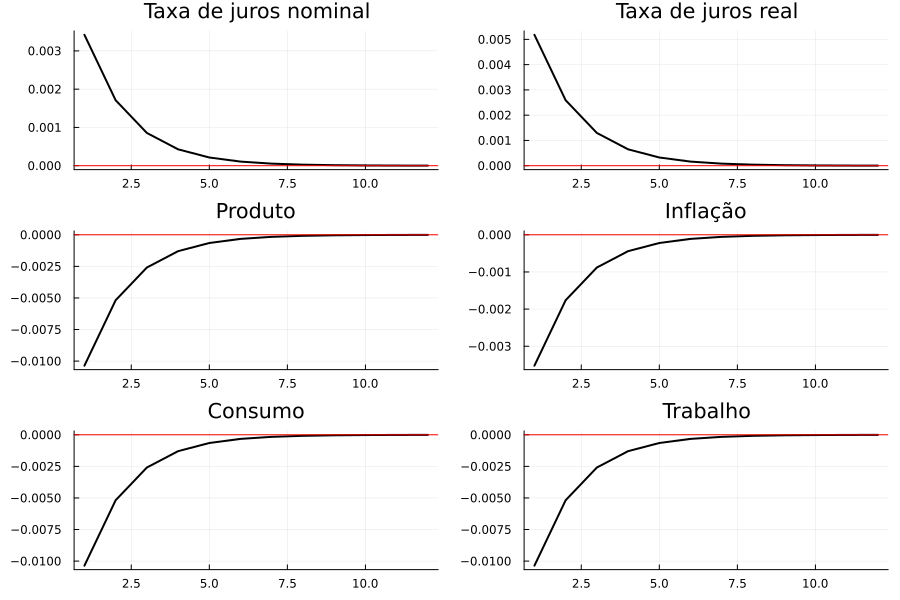

"/workspaces/julia_codespace_template/Sessão 7/NK_nu_IRFs.png"

In [5]:
vars = [Symbol("i"), Symbol("r_real"), Symbol("y"), Symbol("pi"), Symbol("c"), Symbol("n")]
titles = ["Taxa de juros nominal", "Taxa de juros real", "Produto", "Inflação", "Consumo", "Trabalho"]

p = plot(layout = (3, 2), size = (900, 600))

for (i, v) in enumerate(vars)
    plot!(p[i], irf_nu[1:12, v],
          color = :black,
          lw = 2,
          title = titles[i],
          ylabel = "",
          legend = false)
    hline!(p[i], [0], color = :red, lw = 1, linestyle = :solid)
end


display(p)
savefig("NK_nu_IRFs.png")


### **2. Choque de política monetária em economia aberta**

In [6]:
mod1 = read("NK_Abierta.mod", String)
println(mod1)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                   Banco Interamericano de Desarrollo                    %
%                                                                         %
%             Modelo Novo-Keynesiano de Economia Aberta                   %
%                           Janeiro de 2026                               %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

%--------------------------------------------------------------------------
% 1. Definição de variáveis
%--------------------------------------------------------------------------

% Variáveis endógenas

var y_gap pi_h i y_nat r_nat y s pi n m_real r_real w nx c p_h p er d_er y_star p_star a nu;

% Variáveis exógenas

varexo eps_nu eps_a eps_y_star eps_p_star;

% Parâmetros

parameters beta sigma varphi epsilon theta gamma eta eta_m rho_a rho_nu rho_y_star rho_p_star phi_pi phi_y omega sigma_gamma Gamma Psi kappa_gamma Phi_star;

%------

In [7]:
m1 = @dynare("NK_Abierta.mod");

Dynare version: 0.9.18
2026-01-23T18:51:37.908: Starting @dynare NK_Abierta.mod
["NK_Abierta.mod", "language=julia", "json=compute"]
Dynare preprocessor version: 6.4.0+0


Starting preprocessing of the model file ...
Found 22 equation(s).
Evaluating expressions...
Computing static model derivatives (order 1).
Normalizing the static model...
Normalization failed with cutoff, trying symbolic normalization...
Finding the optimal block decomposition of the static model...
16 block(s) found:
  15 recursive block(s) and 1 simultaneous block(s).
  the largest simultaneous block has 3 equation(s)
                                 and 2 feedback variable(s).
Computing dynamic model derivatives (order 2).
Normalizing the dynamic model...
Finding the optimal block decomposition of the dynamic model...
12 block(s) found:
  11 recursive block(s) and 1 simultaneous block(s).
  the largest simultaneous block has 3 equation(s)
                                 and 2 feedback variable(s).
JSON written after Computing step.
Preprocessing completed.


2026-01-23T18:51:37.919: End of preprocessing
2026-01-23T18:51:37.924: Start parse_statements!
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31


Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:44
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while 

2026-01-23T18:51:39.727: End parse_statements!
2026-01-23T18:51:39.728: End parser


In [8]:
irf_nua = m1.results.model_results[1].irfs[Symbol("eps_nu")];

No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found


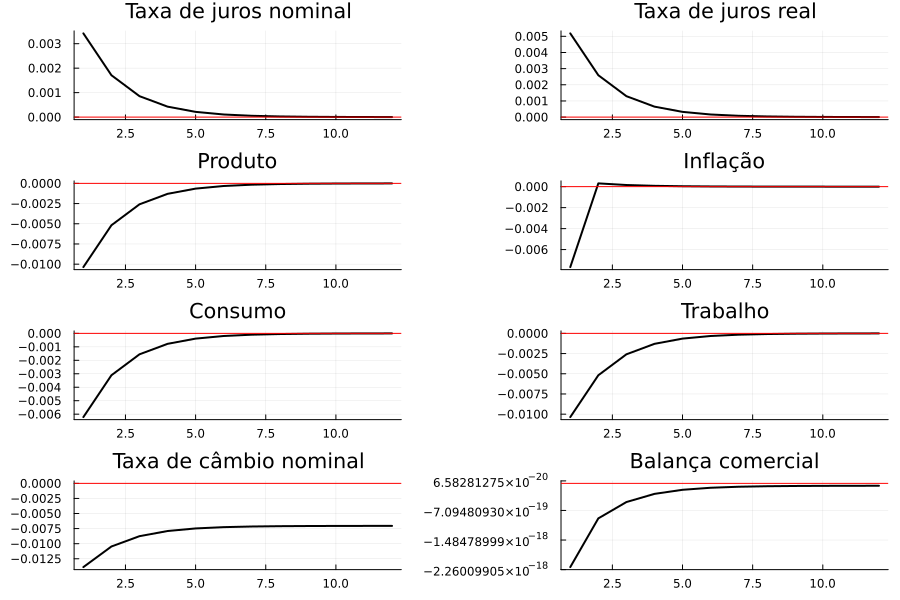

"/workspaces/julia_codespace_template/Sessão 7/NK_nua_IRFs.png"

In [9]:
vars = [Symbol("i"), Symbol("r_real"), Symbol("y"), Symbol("pi"), Symbol("c"), Symbol("n"), Symbol("er"), Symbol("nx")]
titles = ["Taxa de juros nominal", "Taxa de juros real", "Produto", "Inflação", "Consumo", "Trabalho", "Taxa de câmbio nominal", "Balança comercial"]

p = plot(layout = (4, 2), size = (900, 600))

for (i, v) in enumerate(vars)
    plot!(p[i], irf_nua[1:12, v],
          color = :black,
          lw = 2,
          title = titles[i],
          ylabel = "",
          legend = false)
    hline!(p[i], [0], color = :red, lw = 1, linestyle = :solid)
end


display(p)
savefig("NK_nua_IRFs.png")

### **3. Choque de demanda externa em economia aberta**

In [10]:
irf_y_star = m1.results.model_results[1].irfs[Symbol("eps_y_star")];

No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found
No strict ticks found


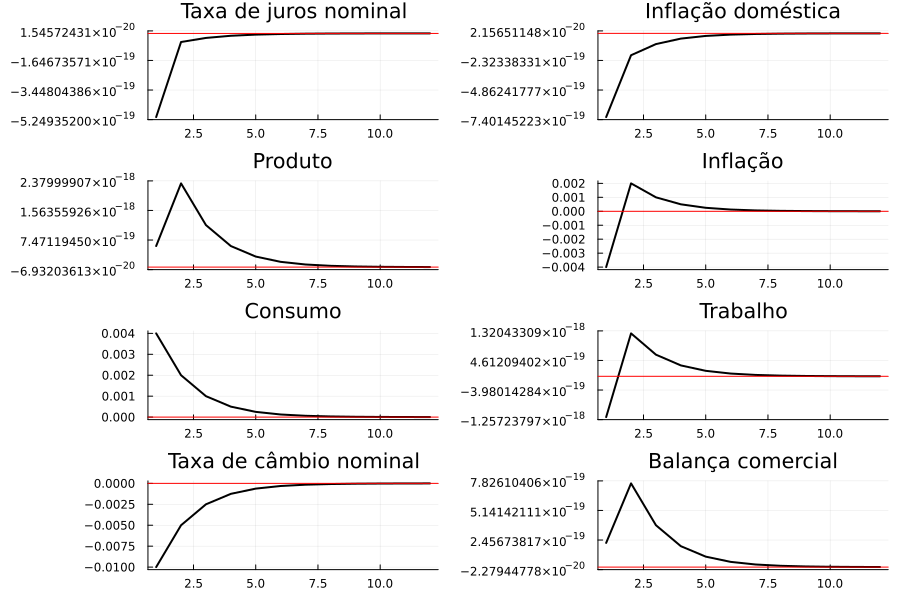

"/workspaces/julia_codespace_template/Sessão 7/NK_y_star_IRFs.png"

In [11]:
vars = [Symbol("i"), Symbol("pi_h"), Symbol("y"), Symbol("pi"), Symbol("c"), Symbol("n"), Symbol("er"), Symbol("nx")]
titles = ["Taxa de juros nominal", "Inflação doméstica", "Produto", "Inflação", "Consumo", "Trabalho", "Taxa de câmbio nominal", "Balança comercial"]

p = plot(layout = (4, 2), size = (900, 600))

for (i, v) in enumerate(vars)
    plot!(p[i], irf_y_star[1:12, v],
          color = :black,
          lw = 2,
          title = titles[i],
          ylabel = "",
          legend = false)
    hline!(p[i], [0], color = :red, lw = 1, linestyle = :solid)
end


display(p)
savefig("NK_y_star_IRFs.png")